In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

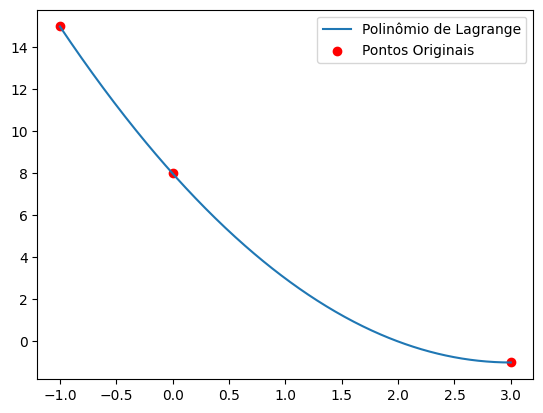

In [2]:
#Forma de Lagrange
def lagrange(xi,yi,N=100):

  n = len(xi)
  #Criamos o vetor x onde queremos avaliar o polinômio (entre o min e max de xi)
  #Função de linear space, cria sequÊncia de nuemros espaçados num intervalo def
  #nl.linspace(ini,fim,qnt)
  x = np.linspace(min(xi),max(xi),N)

  #Matriz L: cada linha i representa o polinômio base L_i avaliado em todo o vetor x
  L = np.ones((n,N))
  for i in range (n):
    for j in range (n):
      if i != j:
        #Fórmula de Lagrange: L_i(x) = Produtorio (x - xj) / (xi - xj)
        L[i,:] = L[i,:]*(x-xi[j])/(xi[i]-xi[j])

  #O polinômio final P(x) é a soma de yi * Li(x)
  #yi tem tamanho (n), L tem (n, N). O resultado 'y' terá tamanho (N)
  #A formula da somatória na teoria remete a um produto escalar do vetor y com os vetores colunas de L
  y = np.dot(yi,L)
  return x,y

pontos_x = np.array([-1,0,3])
pontos_y = np.array([15,8,-1])
x_eval, y_eval = lagrange(pontos_x, pontos_y,500)

#Desenha as linhas, pega cada par (x,y) e liga
plt.plot(x_eval, y_eval, label='Polinômio de Lagrange')
#Desenha pontos isolados, gráfico de dispersão, para destacar os pontos que usamos para interpolação
plt.scatter(pontos_x, pontos_y, color='red', label='Pontos Originais')
#Pega os labels da de cima e monta a legenda
plt.legend()
#Exibe
plt.show()

O polinômio de Lagrange é definido como:$$P(x) = \sum_{i=0}^{n} y_i L_i(x)$$onde cada termo da base é:$$L_i(x) = \prod_{j=0, j \neq i}^{n} \frac{x - x_j}{x_i - x_j}$$

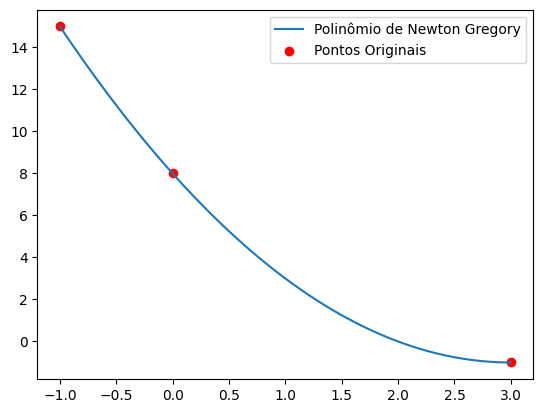

In [3]:
def diferenças_divididas(xi,yi):
  n = len(xi)
  D = np.zeros((n,n))
  #Preenche a 1ª coluna com val de y
  D[:,0] = yi.T
  for j in range (1, n):
    for i in range(j, n):
      #Calcula a inclinação entre os pontos. COmo se fosse um coef angular (delta y/delta x)
      #de forma sucessiva
       D[i,j] = (D[i,j-1]-D[i-1,j-1])/(xi[i]-xi[i-j])

  #C são os coeficientes formados pela diagonal de D que vamos usar
  c=np.diag(D)
  return c,D

def newton_gregory(xi,yi,N=100):
  n = len(xi)
  #Cria 100 pontos no eixo x para o grafico
  x = np.linspace(min(xi),max(xi),N)

  #pega os coef da diagonal de D
  coef, _ = diferenças_divididas(xi,yi)

  #Inicializamos o polinômio com o primeiro coeficiente c0
  y = np.ones(N)*coef[0]
  #Termo do produtório: (x - x0), depois (x - x0)(x - x1),...
  xv = np.ones(N)

  for i in range(1,n):
    #Pega o termo anterior e multiplica por x-xi[i-1]
    xv = xv*(x-xi[i-1])
    #Soma ao resultado a o coef da vez multiplicado pelos termos q estão acumulando
    y = y+coef[i]*xv
  return x,y


pontos_x = np.array([-1,0,3])
pontos_y = np.array([15,8,-1])
x_eval, y_eval = newton_gregory(pontos_x, pontos_y)

#Desenha as linhas, pega cada par (x,y) e liga
plt.plot(x_eval, y_eval, label='Polinômio de Newton Gregory')
#Desenha pontos isolados, gráfico de dispersão, para destacar os pontos que usamos para interpolação
plt.scatter(pontos_x, pontos_y, color='red', label='Pontos Originais')
#Pega os labels da de cima e monta a legenda
plt.legend()
#Exibe
plt.show()


Diferente da forma que aprendemos na escola ($ax^2 + bx + c$), Newton organiza o polinômio de forma "aninhada". Para $n$ pontos, o polinômio é:$$P(x) = c_0 + c_1(x-x_0) + c_2(x-x_0)(x-x_1) + c_3(x-x_0)(x-x_1)(x-x_2) + \dots$$

O termo produtório serve para construir os Polinômios de Base de Newton.Observe o padrão dos termos entre parênteses na fórmula acima:
Para o coeficiente $c_1$, o termo é $(x-x_0)$.

 Para o coeficiente $c_2$, o termo é $(x-x_0)(x-x_1)$.

Para o coeficiente $c_3$, o termo é $(x-x_0)(x-x_1)(x-x_2)$.

Matematicamente, estamos definindo:$$N_i(x) = \prod_{j=0}^{i-1} (x - x_j)$$

Realiza a Somatória (Combinação Linear). Cada coeficiente é uma Diferença Dividida ($c_i$) que você calculou na matriz $D$. A linha de código está executando exatamente esta parte da somatória:$$\sum_{i=1}^{n} c_i \cdot N_i(x)$$

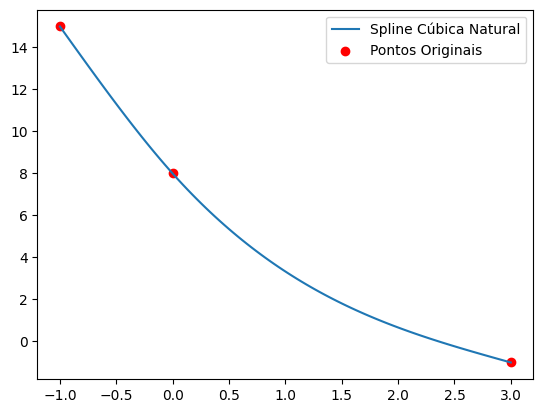

In [4]:
def spline_cubico_natural(xi,yi,N=100):
  n = len(xi)
  x = np.linspace(min(xi),max(xi),N)

  #número de intervalos
  m=n-1
  #vetor de intervalos
  h = np.zeros(n-1)
  #Calcula a distância no eixo x de cada sub-intervalo entre os pontos conhecidos
  h = np.diff(xi) # Calcula xi[i+1] - xi[i] para todos os i de uma vez

  #Matriz A (do sistema linear Ac = r) e o vetor de constantes r
  A = np.zeros((n,n))
  r = np.zeros(n)

  #Define a condição de 'Natural': a curvatura (2ª derivada) nos extremos é zero
  A[0,0] = 1
  A[m,m] = 1

  for i in range (1,n-1):
    #Monta a matriz tridiagonal baseada nas condições de continuidade das derivadas
    A[i,i-1] = h[i-1]
    A[i,i] = 2*(h[i-1]+h[i])
    A[i,i+1] = h[i]

    #Calcula os termos de r baseados nas inclinações (diferenças divididas) dos pontos
    r[i] = 3*((yi[i+1]-yi[i])/h[i]-(yi[i]-yi[i-1])/h[i-1])

  #Resolve o sistema linear para encontrar os coeficientes 'c' (relacionados à 2ª derivada)
  c = np.linalg.solve(A,r)
  #Coeficientes b (inclinação) e d (variação da curvatura) para cada pedaço da curva
  d = np.zeros(m)
  b = np.zeros(m)
  for i in range (m):
    #Fórmulas derivadas da exigência de que os pedaços se conectem perfeitamente
    d[i] = (c[i+1]-c[i])/(3*h[i])
    b[i] = (yi[i+1]-yi[i])/h[i]-(h[i]/3*(2*c[i]+c[i+1]))

  #Vetor de resultados do eixo vertical
  y = np.zeros(N)
  for i in range (N):
    #Determina em qual parte (intervalo) o ponto atual do gráfico se encaixa
    id = m-1
    for j in range (m):
      if x[i] <= xi[j+1]:
        id=j
        #Para qnd encontra o intervalo correto
        break
    #t é a distância local: o quanto o ponto x[i] avançou dentro do seu intervalo específico
    t=(x[i]-xi[id])
    #Calcula y usando o polinômio cúbico daquele intervalo: S(x) = a + bt + ct² + dt³
    y[i] = yi[id] +b[id]*t +c[id]*(t**2) +d[id]*(t**3)

  return x,y

pontos_x = np.array([-1,0,3])
pontos_y = np.array([15,8,-1])
x_eval, y_eval = spline_cubico_natural(pontos_x, pontos_y)

#Desenha as linhas, pega cada par (x,y) e liga
plt.plot(x_eval, y_eval, label='Spline Cúbica Natural')
#Desenha pontos isolados, gráfico de dispersão, para destacar os pontos que usamos para interpolação
plt.scatter(pontos_x, pontos_y, color='red', label='Pontos Originais')
#Pega os labels da de cima e monta a legenda
plt.legend()
#Exibe
plt.show()

1. A Definição do Polinômio:

Para um intervalo $i$, onde $t = x - x_i$, o polinômio é expresso como:$$S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3$$


2. As Condições de Suavidade:

Para que a curva pareça uma única linha contínua e elegante, impomos quatro regras:
- Interpolação: A curva deve tocar os pontos conhecidos ($S_i(x_i) = y_i$).
- Continuidade: Os pedaços devem se tocar no final de cada intervalo ($S_i(x_{i+1}) = S_{i+1}(x_{i+1})$).
- Derivada Primeira (Inclinação): A inclinação deve ser a mesma no ponto de encontro ($S'_i(x_{i+1}) = S'_{i+1}(x_{i+1})$).
- Derivada Segunda (Curvatura): A aceleração da curva deve ser a mesma no ponto de encontro ($S''_i(x_{i+1}) = S''_{i+1}(x_{i+1})$).

3. O Sistema Linear $Ac = r$

O "coração" do seu código é resolver um sistema para encontrar os coeficientes $c_i$, que representam a segunda derivada nos pontos. A relação fundamental derivada das condições acima é:$$h_{i-1}c_{i-1} + 2(h_{i-1} + h_i)c_i + h_i c_{i+1} = 3\left(\frac{y_{i+1}-y_i}{h_i} - \frac{y_i-y_{i-1}}{h_{i-1}}\right)$$Onde $h_i = x_{i+1} - x_i$.A Matriz A: É tridiagonal. Cada linha $i$ contém os pesos $h_{i-1}$, $2(h_{i-1}+h_i)$ e $h_i$.O Vetor r: Contém as diferenças de inclinação entre os intervalos adjacentes.

Exercícios
1. Considere a tabela com os valores abaixo para utilizar os códigos desenvolvidos em sala de aula, com $N = 100$ pontos no intervalo dos dados. Apresente o plot das curvas de polinômios interpoladores por Lagrange, Newton e Splines Cúbica.

- x: 0 / 6 / 10 / 13 / 17 / 20 / 28

- f(x): 6 / 17 / 42 / 37 / 30 / 29 / 28


Método de Lagrange



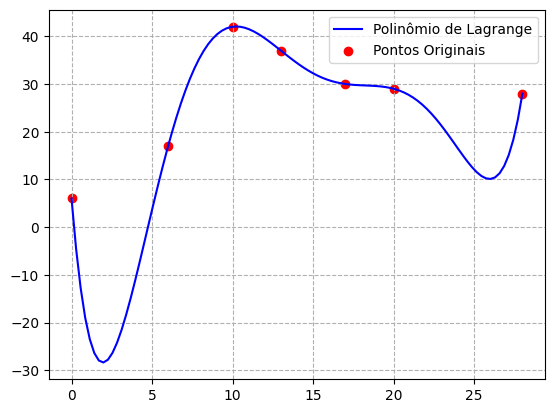

In [28]:
#Resolução Exercício
N = 100
x = np.array([0.,6.,10.,13.,17.,20.,28.])
y = np.array([6.,17.,42.,37.,30.,29.,28.])

#Métodos de Lagrange
x_lagrange, y_lagrange = lagrange(x.copy(),y.copy(),N)

print(f'\nMétodo de Lagrange\n')
plt.plot(x_lagrange, y_lagrange, color='blue', label='Polinômio de Lagrange')
plt.scatter(x, y, color='red', label='Pontos Originais')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()



Método de Newton Gregory



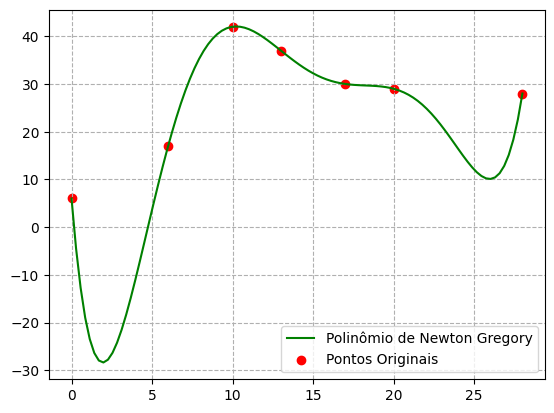

In [29]:
#Resolução Exercício
N = 100
x = np.array([0.,6.,10.,13.,17.,20.,28.])
y = np.array([6.,17.,42.,37.,30.,29.,28.])

#Método de Newton Gregory
x_newton, y_newton = newton_gregory(x.copy(),y.copy())

print(f'\nMétodo de Newton Gregory\n')
plt.plot(x_newton, y_newton, color='green', label='Polinômio de Newton Gregory')
plt.scatter(x, y, color='red', label='Pontos Originais')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


Método de Spline Cúbica Natural



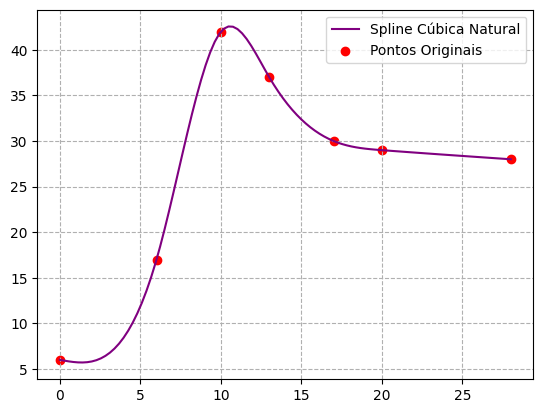

In [30]:
#Resolução Exercício
N = 100
x = np.array([0.,6.,10.,13.,17.,20.,28.])
y = np.array([6.,17.,42.,37.,30.,29.,28.])

#Método de Spline Cúbica Natural
x_spline, y_spline = spline_cubico_natural(x.copy(),y.copy())

print(f'\nMétodo de Spline Cúbica Natural\n')
plt.plot(x_spline, y_spline, color='purple', label='Spline Cúbica Natural')
plt.scatter(x, y, color='red', label='Pontos Originais')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

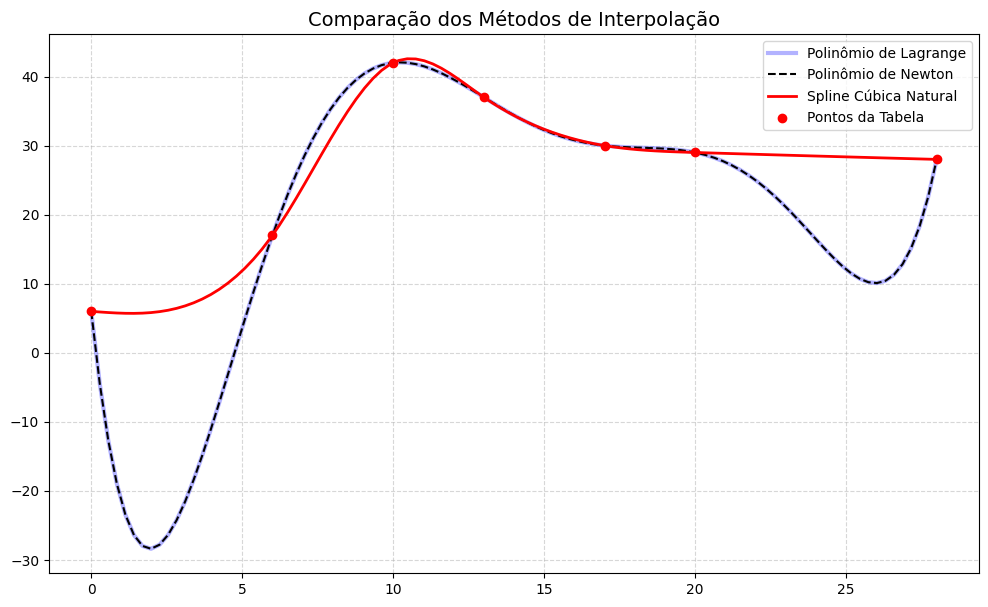

In [33]:
#Gráfico único
print('\n\n')
plt.figure(figsize=(12, 7))
plt.plot(x_lagrange, y_lagrange, color='blue', label='Polinômio de Lagrange', linewidth=3, alpha=0.3)
plt.plot(x_newton, y_newton, color='black', linestyle='--', label='Polinômio de Newton')
plt.plot(x_spline, y_spline, color='red', label='Spline Cúbica Natural', linewidth=2)
plt.scatter(x, y, color='red', zorder=5, label='Pontos da Tabela')
plt.title('Comparação dos Métodos de Interpolação', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()